# Sentinela — Motor Preditivo (Sprint 3)

## 1. Objetivo
mplementar e validar o Motor Preditivo do Sentinela para o volume
total de incidentes (D+1 e D+7) e para as prioridades P2 e P3. As quatro capacidades
seguem a mesma validação temporal, mas atingem níveis distintos de maturidade

## 2. Preparação dos Dados

Série diária produzida em `01_eda_preparacao.ipynb`, que identificou mudança de regime a
partir de setembro/2025. Validação mínima antes da modelagem.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBRegressor

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (11, 4.5)

RANDOM_STATE = 42
PROCESSED_PATH = '/content/serie_diaria_2025.csv'
REGIME_INICIO = '2025-09-01'   # início do regime recente, identificado na Etapa 1 (EDA)

In [ ]:
df = pd.read_csv(PROCESSED_PATH, parse_dates=['data']).sort_values('data').reset_index(drop=True)

print('Período:', df['data'].min().date(), 'a', df['data'].max().date())
print('Observações:', len(df))
print('Datas duplicadas:', df['data'].duplicated().sum())
print('Ordenação temporal correta:', df['data'].is_monotonic_increasing)
print('Nulos por coluna:')
print(df.isnull().sum().to_string())

df.head()

Período: 2025-01-01 a 2025-12-31
Observações: 365
Datas duplicadas: 0
Ordenação temporal correta: True
Nulos por coluna:
data                         0
volume_total                 0
volume_p2                    0
volume_p3                    0
volume_outras_prioridades    0


,data,volume_total,volume_p2,volume_p3,volume_outras_prioridades
0,2025-01-01,34,5,6,23
1,2025-01-02,55,5,38,12
2,2025-01-03,77,11,40,26
3,2025-01-04,166,139,10,17
4,2025-01-05,39,11,7,21


Série íntegra: sem duplicidade, sem lacunas, sem nulos. `volume_p2 + volume_p3 +
volume_outras_prioridades = volume_total`.

## 3. Estratégia de Validação

- Treino sempre anterior ao teste, sem split aleatório.
- Walk-forward: teste dividido em blocos consecutivos; o treino se expande a cada bloco.
- Features calculadas apenas com dados até `t`; o alvo é sempre posterior a `t` (sem leakage).
- Modelos treinados a partir do regime recente (`>= 2025-09-01`).
- Cada modelo é comparado contra o baseline mais forte disponível
- Métricas: MAE, RMSE, resultado por janela e fração de janelas vencidas.

In [ ]:
def gerar_janelas_walk_forward(n_observacoes, treino_inicial, n_janelas):
    """
    Divide um conjunto de observações em janelas walk-forward com treino expansivo.

    - As primeiras `treino_inicial` observações formam o treino de aquecimento.
    - As observações restantes são divididas em `n_janelas` blocos de teste consecutivos.
    - A cada janela, o treino se expande para incluir o bloco de teste da janela anterior.

    Retorna uma lista de tuplas (treino_inicio, treino_fim, teste_inicio, teste_fim),
    todos como índices posicionais (não rótulos).
    """
    restante = n_observacoes - treino_inicial
    tamanho_bloco = restante // n_janelas

    janelas = []
    treino_fim = treino_inicial - 1
    teste_inicio = treino_inicial
    for i in range(n_janelas):
        teste_fim = teste_inicio + tamanho_bloco - 1
        if i == n_janelas - 1:
            teste_fim = n_observacoes - 1  # a última janela absorve os dias restantes
        janelas.append((0, treino_fim, teste_inicio, teste_fim))
        treino_fim = teste_fim
        teste_inicio = teste_fim + 1
    return janelas

### 3.1 Validação do regime de treinamento

O conjunto de treino varia:
**A)** apenas o regime recente; **B)** histórico completo, com um indicador causal de
regime.

In [ ]:
df_regime = df.copy()
df_regime['target_d1'] = df_regime['volume_total'].shift(-1)
df_regime['lag_1'] = df_regime['volume_total']
df_regime['lag_7'] = df_regime['volume_total'].shift(6)
df_regime['media_7d'] = df_regime['volume_total'].rolling(7).mean()
df_regime['dia_semana_target'] = df_regime['data'].shift(-1).dt.dayofweek
df_regime['fim_semana_target'] = df_regime['dia_semana_target'].isin([5, 6]).astype(int)
df_regime['regime_recente'] = (df_regime['data'] >= REGIME_INICIO).astype(int)  # indicador causal

FEATURES_REGIME_A = ['lag_1', 'lag_7', 'media_7d', 'dia_semana_target', 'fim_semana_target']
FEATURES_REGIME_B = FEATURES_REGIME_A + ['regime_recente']

df_regime = df_regime.dropna(subset=FEATURES_REGIME_B + ['target_d1']).reset_index(drop=True)
regime_pool_teste = df_regime[df_regime['data'] >= REGIME_INICIO].reset_index(drop=True)

janelas_regime = gerar_janelas_walk_forward(len(regime_pool_teste), treino_inicial=30, n_janelas=3)

resultados_regime = []
reais_regime, preds_a_regime, preds_b_regime, base_regime = [], [], [], []

for i, (tr0, tr1, te0, te1) in enumerate(janelas_regime, 1):
    teste = regime_pool_teste.iloc[te0:te1 + 1]
    teste_inicio = teste['data'].iloc[0]

    y_teste = teste['target_d1'].values
    pred_baseline = teste['media_7d'].values

    # Estratégia A: treino restrito ao regime recente
    treino_a = regime_pool_teste.iloc[tr0:tr1 + 1]
    modelo_a = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=RANDOM_STATE)
    modelo_a.fit(treino_a[FEATURES_REGIME_A], treino_a['target_d1'])
    pred_a = modelo_a.predict(teste[FEATURES_REGIME_A])

    # Estratégia B: treino com todo o histórico anterior ao início do bloco de teste
    treino_b = df_regime[df_regime['data'] < teste_inicio]
    modelo_b = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=RANDOM_STATE)
    modelo_b.fit(treino_b[FEATURES_REGIME_B], treino_b['target_d1'])
    pred_b = modelo_b.predict(teste[FEATURES_REGIME_B])

    mae_base_j = mean_absolute_error(y_teste, pred_baseline)
    mae_a_j = mean_absolute_error(y_teste, pred_a)
    mae_b_j = mean_absolute_error(y_teste, pred_b)

    resultados_regime.append({
        'Janela': i,
        'Melhoria A vs baseline (%)': round((mae_base_j - mae_a_j) / mae_base_j * 100, 1),
        'Melhoria B vs baseline (%)': round((mae_base_j - mae_b_j) / mae_base_j * 100, 1),
    })

    reais_regime.extend(y_teste); preds_a_regime.extend(pred_a); preds_b_regime.extend(pred_b)
    base_regime.extend(pred_baseline)

tabela_janelas_regime = pd.DataFrame(resultados_regime)
tabela_janelas_regime

,Janela,Melhoria A vs baseline (%),Melhoria B vs baseline (%)
0,1,32.9,27.1
1,2,-21.5,-16.3
2,3,1.1,-3.7


In [ ]:
mae_base_regime = mean_absolute_error(reais_regime, base_regime)
rmse_base_regime = mean_squared_error(reais_regime, base_regime) ** 0.5
mae_a_regime = mean_absolute_error(reais_regime, preds_a_regime)
rmse_a_regime = mean_squared_error(reais_regime, preds_a_regime) ** 0.5
mae_b_regime = mean_absolute_error(reais_regime, preds_b_regime)
rmse_b_regime = mean_squared_error(reais_regime, preds_b_regime) ** 0.5

janelas_pos_a = (tabela_janelas_regime['Melhoria A vs baseline (%)'] > 0).sum()
janelas_pos_b = (tabela_janelas_regime['Melhoria B vs baseline (%)'] > 0).sum()

comparacao_regime = pd.DataFrame([
    {'Estratégia': 'A — Regime recente', 'MAE': round(mae_a_regime, 1), 'RMSE': round(rmse_a_regime, 1),
     'Melhoria vs baseline': f'{(mae_base_regime - mae_a_regime) / mae_base_regime * 100:+.1f}%',
     'Janelas positivas': f'{janelas_pos_a}/{len(tabela_janelas_regime)}'},
    {'Estratégia': 'B — Histórico completo + regime', 'MAE': round(mae_b_regime, 1), 'RMSE': round(rmse_b_regime, 1),
     'Melhoria vs baseline': f'{(mae_base_regime - mae_b_regime) / mae_base_regime * 100:+.1f}%',
     'Janelas positivas': f'{janelas_pos_b}/{len(tabela_janelas_regime)}'},
])
comparacao_regime

,Estratégia,MAE,RMSE,Melhoria vs baseline,Janelas positivas
0,A — Regime recente,117.6,163.8,+8.2%,2/3
1,B — Histórico completo + regime,120.7,166.7,+5.8%,1/3


**Decisão:** o treinamento no regime recente apresentou menor erro agregado (MAE 117,6 vs.
120,7), maior número de janelas positivas e melhor desempenho no período mais recente
(J3). A Estratégia B foi superior apenas na J2. Por isso, o regime iniciado em
setembro/2025 foi mantido como configuração do Motor Preditivo

## 4. Previsão de Volume — D+1

Alvo: volume total em `t+1`. Features: `lag_1`, `lag_7`, `media_7d` e calendário do alvo.
Baseline mais forte: `media_7d`. Entre as famílias avaliadas na etapa experimental, o
RandomForest apresentou o melhor equilíbrio entre erro e estabilidade.

**Premissa operacional:** `lag_1` é o volume total já fechado do dia corrente (`t`). Isso pressupõe que a previsão de D+1 é gerada **após o fechamento do dia `t`** (ex.: execução noturna/madrugada), quando o volume de `t` já está consolidado. Rodar o modelo antes do fechamento de `t` invalidaria essa feature.

In [ ]:
df_d1 = df.copy()
df_d1['target_d1'] = df_d1['volume_total'].shift(-1)

df_d1['lag_1'] = df_d1['volume_total']
df_d1['lag_7'] = df_d1['volume_total'].shift(6)
df_d1['media_7d'] = df_d1['volume_total'].rolling(7).mean()
df_d1['dia_semana_target'] = df_d1['data'].shift(-1).dt.dayofweek
df_d1['fim_semana_target'] = df_d1['dia_semana_target'].isin([5, 6]).astype(int)

FEATURES_D1 = ['lag_1', 'lag_7', 'media_7d', 'dia_semana_target', 'fim_semana_target']

df_d1 = df_d1.dropna(subset=FEATURES_D1 + ['target_d1']).reset_index(drop=True)
regime_d1 = df_d1[df_d1['data'] >= REGIME_INICIO].reset_index(drop=True)

print('Observações no regime recente:', len(regime_d1))
print('Período:', regime_d1['data'].min().date(), 'a', regime_d1['data'].max().date())

Observações no regime recente: 121
Período: 2025-09-01 a 2025-12-30


In [ ]:
janelas_d1 = gerar_janelas_walk_forward(len(regime_d1), treino_inicial=30, n_janelas=3)

resultados_d1 = []
reais_d1, previstos_d1, baseline_d1, datas_d1 = [], [], [], []

for i, (tr0, tr1, te0, te1) in enumerate(janelas_d1, 1):
    treino = regime_d1.iloc[tr0:tr1 + 1]
    teste = regime_d1.iloc[te0:te1 + 1]

    y_teste = teste['target_d1'].values
    pred_baseline = teste['media_7d'].values

    modelo = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=RANDOM_STATE)
    modelo.fit(treino[FEATURES_D1], treino['target_d1'])
    pred_modelo = modelo.predict(teste[FEATURES_D1])

    mae_baseline = mean_absolute_error(y_teste, pred_baseline)
    mae_modelo = mean_absolute_error(y_teste, pred_modelo)
    melhoria = (mae_baseline - mae_modelo) / mae_baseline * 100

    resultados_d1.append({
        'Janela': i, 'MAE baseline': round(mae_baseline, 1), 'MAE RandomForest': round(mae_modelo, 1),
        'Melhoria (%)': round(melhoria, 1)
    })

    reais_d1.extend(y_teste); previstos_d1.extend(pred_modelo); baseline_d1.extend(pred_baseline)
    datas_d1.extend(teste['data'] + pd.Timedelta(days=1))

tabela_d1 = pd.DataFrame(resultados_d1)
tabela_d1

,Janela,MAE baseline,MAE RandomForest,Melhoria (%)
0,1,164.1,110.2,32.9
1,2,107.7,130.8,-21.5
2,3,113.3,112.1,1.1


In [ ]:
mae_baseline_d1 = mean_absolute_error(reais_d1, baseline_d1)
rmse_baseline_d1 = mean_squared_error(reais_d1, baseline_d1) ** 0.5
mae_modelo_d1 = mean_absolute_error(reais_d1, previstos_d1)
rmse_modelo_d1 = mean_squared_error(reais_d1, previstos_d1) ** 0.5
melhoria_d1 = (mae_baseline_d1 - mae_modelo_d1) / mae_baseline_d1 * 100
janelas_positivas_d1 = (tabela_d1['Melhoria (%)'] > 0).sum()

print(f'MAE baseline (media_7d):     {mae_baseline_d1:.1f}')
print(f'RMSE baseline (media_7d):    {rmse_baseline_d1:.1f}')
print(f'MAE RandomForest:             {mae_modelo_d1:.1f}')
print(f'RMSE RandomForest:            {rmse_modelo_d1:.1f}')
print(f'Melhoria agregada:            {melhoria_d1:.1f}%')
print(f'Janelas com melhoria positiva: {janelas_positivas_d1} de {len(tabela_d1)}')

MAE baseline (media_7d):     128.2
RMSE baseline (media_7d):    168.2
MAE RandomForest:             117.6
RMSE RandomForest:            163.8
Melhoria agregada:            8.2%
Janelas com melhoria positiva: 2 de 3


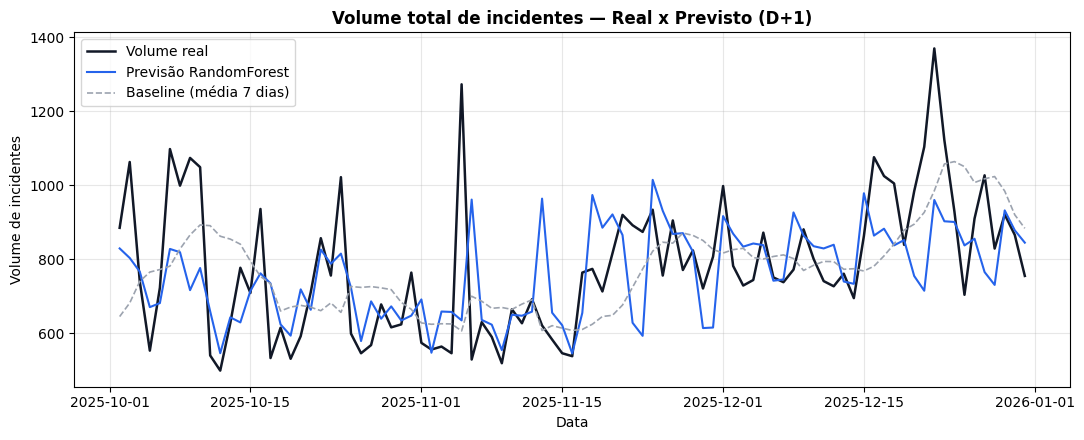

In [ ]:
fig, ax = plt.subplots()
ax.plot(datas_d1, reais_d1, label='Volume real', color='#111827', linewidth=1.8)
ax.plot(datas_d1, previstos_d1, label='Previsão RandomForest', color='#2563eb', linewidth=1.5)
ax.plot(datas_d1, baseline_d1, label='Baseline (média 7 dias)', color='#9ca3af', linewidth=1.2, linestyle='--')
ax.set_title('Volume total de incidentes — Real x Previsto (D+1)', fontsize=12, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Volume de incidentes')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

RandomForest: MAE 117,6 contra 128,2 do baseline, com redução de 8,2%. Superior em 2 das 3
janelas; a janela restante ficou abaixo do baseline, resultado mantido sem ajuste.

**Status: Validado com ressalvas.**

## 5. Previsão de Volume — D+7

Alvo: soma do volume total de `t+1` a `t+7`. A previsão direta do valor acumulado teve
desempenho inferior ao baseline; a previsão é decomposta em 7 modelos diários, somados:

```
dados até t → previsão t+1 → t+2 → ... → t+7 → soma = volume da semana
```

Features: `lag_1`, `lag_7`, `media_7d`, `volume_acumulado_7d` (também baseline), tendência
(média 3d − média 7d) e volatilidade (desvio-padrão 7d). Modelo: Ridge, um por horizonte.
Avaliação em pontos espaçados de 7 dias, para previsões semanais independentes.

In [ ]:
df_d7 = df.copy()

for h in range(1, 8):
    df_d7[f'target_p_d{h}'] = df_d7['volume_total'].shift(-h)
df_d7['target_semana'] = df_d7[[f'target_p_d{h}' for h in range(1, 8)]].sum(axis=1, min_count=7)

df_d7['lag_1'] = df_d7['volume_total']
df_d7['lag_7'] = df_d7['volume_total'].shift(6)
df_d7['media_7d'] = df_d7['volume_total'].rolling(7).mean()
df_d7['volume_acumulado_7d'] = df_d7['volume_total'].rolling(7).sum()
df_d7['tendencia_3_7'] = df_d7['volume_total'].rolling(3).mean() - df_d7['volume_total'].rolling(7).mean()
df_d7['volatilidade_7d'] = df_d7['volume_total'].rolling(7).std()
df_d7['dia_semana_ref'] = df_d7['data'].dt.dayofweek

FEATURES_D7 = ['lag_1', 'lag_7', 'media_7d', 'volume_acumulado_7d', 'tendencia_3_7', 'volatilidade_7d', 'dia_semana_ref']
targets_horizonte = [f'target_p_d{h}' for h in range(1, 8)]

df_d7 = df_d7.dropna(subset=FEATURES_D7 + targets_horizonte).reset_index(drop=True)
regime_d7 = df_d7[df_d7['data'] >= REGIME_INICIO].reset_index(drop=True)

print('Observações no regime recente:', len(regime_d7))

Observações no regime recente: 115


In [ ]:
janelas_d7 = gerar_janelas_walk_forward(len(regime_d7), treino_inicial=40, n_janelas=2)

resultados_d7 = []
reais_d7, previstos_d7, baseline_d7, datas_d7 = [], [], [], []

for i, (tr0, tr1, te0, te1) in enumerate(janelas_d7, 1):
    treino = regime_d7.iloc[tr0:tr1 + 1]
    teste_bloco = regime_d7.iloc[te0:te1 + 1]
    teste = teste_bloco.iloc[::7]  # pontos espaçados de 7 dias — previsões semanais independentes

    previsoes_horizonte = {}
    for h in range(1, 8):
        modelo_h = make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=RANDOM_STATE))
        modelo_h.fit(treino[FEATURES_D7], treino[f'target_p_d{h}'])
        previsoes_horizonte[h] = modelo_h.predict(teste[FEATURES_D7])

    pred_semana = sum(previsoes_horizonte[h] for h in range(1, 8))
    y_teste = teste['target_semana'].values
    pred_baseline = teste['volume_acumulado_7d'].values

    mae_baseline = mean_absolute_error(y_teste, pred_baseline)
    mae_modelo = mean_absolute_error(y_teste, pred_semana)
    melhoria = (mae_baseline - mae_modelo) / mae_baseline * 100

    resultados_d7.append({
        'Janela': i, 'Previsões independentes': len(teste),
        'MAE baseline': round(mae_baseline, 1), 'MAE Ridge multi-horizonte': round(mae_modelo, 1),
        'Melhoria (%)': round(melhoria, 1)
    })

    reais_d7.extend(y_teste); previstos_d7.extend(pred_semana); baseline_d7.extend(pred_baseline)
    datas_d7.extend(teste['data'] + pd.Timedelta(days=1))

tabela_d7 = pd.DataFrame(resultados_d7)
tabela_d7

,Janela,Previsões independentes,MAE baseline,MAE Ridge multi-horizonte,Melhoria (%)
0,1,6,721.2,382.2,47.0
1,2,6,843.8,807.1,4.4


In [ ]:
mae_baseline_d7 = mean_absolute_error(reais_d7, baseline_d7)
rmse_baseline_d7 = mean_squared_error(reais_d7, baseline_d7) ** 0.5
mae_modelo_d7 = mean_absolute_error(reais_d7, previstos_d7)
rmse_modelo_d7 = mean_squared_error(reais_d7, previstos_d7) ** 0.5
melhoria_d7 = (mae_baseline_d7 - mae_modelo_d7) / mae_baseline_d7 * 100
janelas_positivas_d7 = (tabela_d7['Melhoria (%)'] > 0).sum()

print(f'MAE baseline (últimos 7 dias): {mae_baseline_d7:.1f}')
print(f'RMSE baseline:                 {rmse_baseline_d7:.1f}')
print(f'MAE Ridge multi-horizonte:     {mae_modelo_d7:.1f}')
print(f'RMSE Ridge multi-horizonte:    {rmse_modelo_d7:.1f}')
print(f'Melhoria agregada:             {melhoria_d7:.1f}%')
print(f'Janelas com melhoria positiva: {janelas_positivas_d7} de {len(tabela_d7)}')
print(f'Número de previsões semanais independentes: {len(reais_d7)}')

MAE baseline (últimos 7 dias): 782.5
RMSE baseline:                 971.3
MAE Ridge multi-horizonte:     594.6
RMSE Ridge multi-horizonte:    825.4
Melhoria agregada:             24.0%
Janelas com melhoria positiva: 2 de 2
Número de previsões semanais independentes: 12


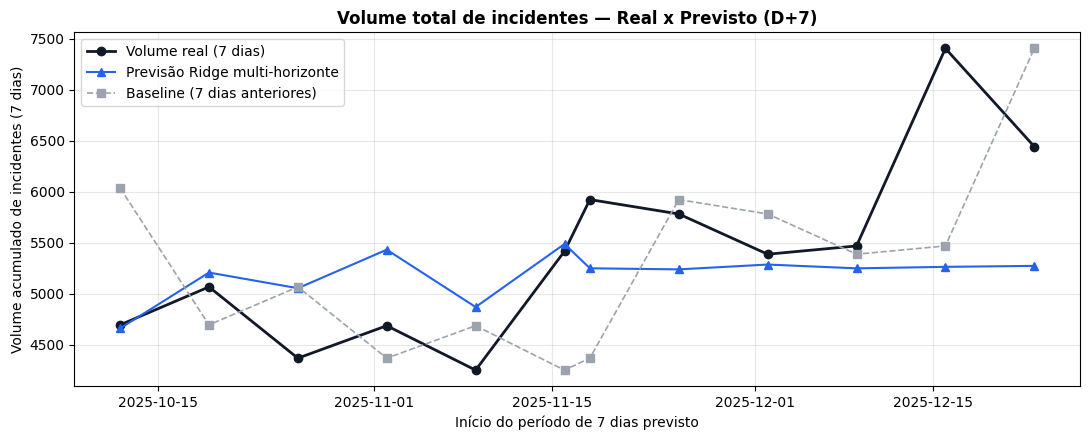

In [ ]:
fig, ax = plt.subplots()
ax.plot(datas_d7, reais_d7, label='Volume real (7 dias)', color='#111827', linewidth=2, marker='o')
ax.plot(datas_d7, previstos_d7, label='Previsão Ridge multi-horizonte', color='#2563eb', linewidth=1.5, marker='^')
ax.plot(datas_d7, baseline_d7, label='Baseline (7 dias anteriores)', color='#9ca3af', linewidth=1.2, linestyle='--', marker='s')
ax.set_title('Volume total de incidentes — Real x Previsto (D+7)', fontsize=12, fontweight='bold')
ax.set_xlabel('Início do período de 7 dias previsto')
ax.set_ylabel('Volume acumulado de incidentes (7 dias)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Ridge multi-horizonte: MAE 594,6 contra 782,5 do baseline (+24,0%), sendo superior nas 2
janelas avaliadas, com 12 previsões semanais independentes.

**Status: Experimental.**

## 6. Previsão por Prioridade — P2

Alvo: volume de P2 em `t+1`. Features: `p2_lag_1`, `p2_lag_7`, `p2_media_7d` e calendário
do alvo. Baseline mais forte: média histórica por dia da semana (`sazonal_dow`), causal e
alinhada ao dia da semana do alvo (`t+1`), não ao de `t`. Modelo: ElasticNet.

In [ ]:
df_p2 = df.copy()
df_p2['target_p2_d1'] = df_p2['volume_p2'].shift(-1)

df_p2['p2_lag_1'] = df_p2['volume_p2']
df_p2['p2_lag_7'] = df_p2['volume_p2'].shift(6)
df_p2['p2_media_7d'] = df_p2['volume_p2'].rolling(7).mean()
df_p2['dia_semana_target'] = df_p2['data'].shift(-1).dt.dayofweek
df_p2['fim_semana_target'] = df_p2['dia_semana_target'].isin([5, 6]).astype(int)

df_p2['dow'] = df_p2['data'].dt.dayofweek
# média causal por dia da semana (própria data), usando apenas ocorrências anteriores (shift(1))
df_p2['media_causal_por_dow'] = df_p2.groupby('dow')['volume_p2'].transform(lambda s: s.expanding().mean().shift(1))
# alinhamento ao target: o valor relevante para prever t+1 é a média sazonal do dia da
# semana de t+1 (dia_semana_target), não a do dia de referência t — por isso desloca-se a
# coluna em -1 para trazer, na linha t, o valor causal já calculado para a data t+1
df_p2['p2_sazonal_dow'] = df_p2['media_causal_por_dow'].shift(-1)

FEATURES_P2 = ['p2_lag_1', 'p2_lag_7', 'p2_media_7d', 'dia_semana_target', 'fim_semana_target']

df_p2 = df_p2.dropna(subset=FEATURES_P2 + ['p2_sazonal_dow', 'target_p2_d1']).reset_index(drop=True)
regime_p2 = df_p2[df_p2['data'] >= REGIME_INICIO].reset_index(drop=True)

print('Observações no regime recente:', len(regime_p2))

Observações no regime recente: 121


In [ ]:
janelas_p2 = gerar_janelas_walk_forward(len(regime_p2), treino_inicial=30, n_janelas=3)

resultados_p2 = []
reais_p2, previstos_p2, baseline_p2, datas_p2 = [], [], [], []

for i, (tr0, tr1, te0, te1) in enumerate(janelas_p2, 1):
    treino = regime_p2.iloc[tr0:tr1 + 1]
    teste = regime_p2.iloc[te0:te1 + 1]

    y_teste = teste['target_p2_d1'].values
    pred_baseline = teste['p2_sazonal_dow'].values

    modelo = make_pipeline(StandardScaler(), ElasticNet(alpha=0.5, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=5000))
    modelo.fit(treino[FEATURES_P2], treino['target_p2_d1'])
    pred_modelo = modelo.predict(teste[FEATURES_P2])

    mae_baseline = mean_absolute_error(y_teste, pred_baseline)
    mae_modelo = mean_absolute_error(y_teste, pred_modelo)
    melhoria = (mae_baseline - mae_modelo) / mae_baseline * 100

    resultados_p2.append({
        'Janela': i, 'MAE baseline': round(mae_baseline, 1), 'MAE ElasticNet': round(mae_modelo, 1),
        'Melhoria (%)': round(melhoria, 1)
    })

    reais_p2.extend(y_teste); previstos_p2.extend(pred_modelo); baseline_p2.extend(pred_baseline)
    datas_p2.extend(teste['data'] + pd.Timedelta(days=1))

tabela_p2 = pd.DataFrame(resultados_p2)
tabela_p2

,Janela,MAE baseline,MAE ElasticNet,Melhoria (%)
0,1,58.4,46.7,20.0
1,2,66.3,55.1,17.0
2,3,33.2,47.6,-43.4


In [ ]:
mae_baseline_p2 = mean_absolute_error(reais_p2, baseline_p2)
rmse_baseline_p2 = mean_squared_error(reais_p2, baseline_p2) ** 0.5
mae_modelo_p2 = mean_absolute_error(reais_p2, previstos_p2)
rmse_modelo_p2 = mean_squared_error(reais_p2, previstos_p2) ** 0.5
melhoria_p2 = (mae_baseline_p2 - mae_modelo_p2) / mae_baseline_p2 * 100
janelas_positivas_p2 = (tabela_p2['Melhoria (%)'] > 0).sum()

print(f'MAE baseline (sazonal_dow):    {mae_baseline_p2:.1f}')
print(f'RMSE baseline:                 {rmse_baseline_p2:.1f}')
print(f'MAE ElasticNet:                {mae_modelo_p2:.1f}')
print(f'RMSE ElasticNet:               {rmse_modelo_p2:.1f}')
print(f'Melhoria agregada:             {melhoria_p2:.1f}%')
print(f'Janelas com melhoria positiva: {janelas_positivas_p2} de {len(tabela_p2)}')

MAE baseline (sazonal_dow):    52.4
RMSE baseline:                 99.6
MAE ElasticNet:                49.8
RMSE ElasticNet:               87.5
Melhoria agregada:             5.1%
Janelas com melhoria positiva: 2 de 3


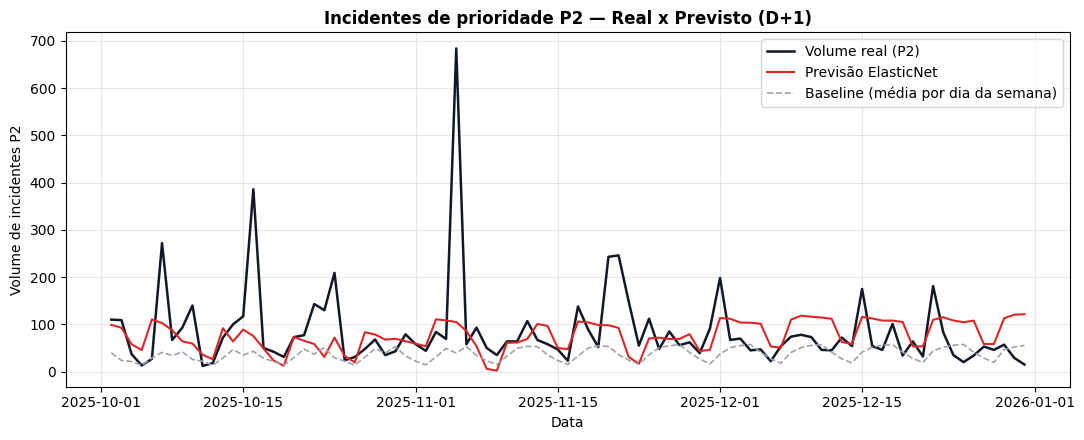

In [ ]:
fig, ax = plt.subplots()
ax.plot(datas_p2, reais_p2, label='Volume real (P2)', color='#111827', linewidth=1.8)
ax.plot(datas_p2, previstos_p2, label='Previsão ElasticNet', color='#dc2626', linewidth=1.5)
ax.plot(datas_p2, baseline_p2, label='Baseline (média por dia da semana)', color='#9ca3af', linewidth=1.2, linestyle='--')
ax.set_title('Incidentes de prioridade P2 — Real x Previsto (D+1)', fontsize=12, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Volume de incidentes P2')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ElasticNet: MAE 49,8 contra 52,4 do baseline corrigido (+5,1%). Superior em 2 das 3
janelas; a mais recente piorou (−43,4%).

**Status: Validado com ressalvas.**

## 7. Previsão por Prioridade — P3

Modelada inicialmente como série independente, com as mesmas features de P2 e baseline
`p3_media_7d`. Nenhum modelo direto superou o baseline:

In [ ]:
df_p3_direto = df.copy()
df_p3_direto['target_p3_d1'] = df_p3_direto['volume_p3'].shift(-1)
df_p3_direto['p3_lag_1'] = df_p3_direto['volume_p3']
df_p3_direto['p3_lag_7'] = df_p3_direto['volume_p3'].shift(6)
df_p3_direto['p3_media_7d'] = df_p3_direto['volume_p3'].rolling(7).mean()
df_p3_direto['dia_semana_target'] = df_p3_direto['data'].shift(-1).dt.dayofweek
df_p3_direto['fim_semana_target'] = df_p3_direto['dia_semana_target'].isin([5, 6]).astype(int)

FEATURES_P3_DIRETO = ['p3_lag_1', 'p3_lag_7', 'p3_media_7d', 'dia_semana_target', 'fim_semana_target']
df_p3_direto = df_p3_direto.dropna(subset=FEATURES_P3_DIRETO + ['target_p3_d1']).reset_index(drop=True)
regime_p3_direto = df_p3_direto[df_p3_direto['data'] >= REGIME_INICIO].reset_index(drop=True)

janelas_p3_direto = gerar_janelas_walk_forward(len(regime_p3_direto), treino_inicial=30, n_janelas=3)

def avaliar_modelo_direto(nome_modelo, construtor):
    reais, previstos = [], []
    for (tr0, tr1, te0, te1) in janelas_p3_direto:
        treino = regime_p3_direto.iloc[tr0:tr1 + 1]
        teste = regime_p3_direto.iloc[te0:te1 + 1]
        modelo = construtor()
        modelo.fit(treino[FEATURES_P3_DIRETO], treino['target_p3_d1'])
        previstos.extend(modelo.predict(teste[FEATURES_P3_DIRETO]))
        reais.extend(teste['target_p3_d1'].values)
    return mean_absolute_error(reais, previstos)

baseline_direto_reais, baseline_direto_preds = [], []
for (tr0, tr1, te0, te1) in janelas_p3_direto:
    teste = regime_p3_direto.iloc[te0:te1 + 1]
    baseline_direto_reais.extend(teste['target_p3_d1'].values)
    baseline_direto_preds.extend(teste['p3_media_7d'].values)
mae_baseline_direto = mean_absolute_error(baseline_direto_reais, baseline_direto_preds)

modelos_diretos = {
    'RandomForest': lambda: RandomForestRegressor(n_estimators=200, max_depth=4, random_state=RANDOM_STATE),
    'Ridge': lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    'ElasticNet': lambda: make_pipeline(StandardScaler(), ElasticNet(alpha=0.5, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=5000)),
    'XGBoost': lambda: XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE),
}

tabela_p3_direto = pd.DataFrame([
    {'Modelo direto': nome, 'MAE': round(avaliar_modelo_direto(nome, construtor), 1),
     'Resultado vs baseline (%)': round((mae_baseline_direto - avaliar_modelo_direto(nome, construtor)) / mae_baseline_direto * 100, 1)}
    for nome, construtor in modelos_diretos.items()
]).sort_values('MAE')

print(f'MAE do baseline (p3_media_7d): {mae_baseline_direto:.1f}')
tabela_p3_direto

MAE do baseline (p3_media_7d): 59.6


,Modelo direto,MAE,Resultado vs baseline (%)
2,ElasticNet,77.1,-29.4
1,Ridge,79.4,-33.3
3,XGBoost,82.2,-37.9
0,RandomForest,89.9,-50.9


Como o volume total é mais previsível (Seção 4), P3 passou a ser estimado como
composição do total:

```
Previsão Total D+1 × Participação P3/Total (últimos 3 dias) = Previsão P3 D+1
```

Participação calculada apenas com dados até `t`. A previsão do total é treinada de forma
independente em cada janela.

In [ ]:
df_p3 = df.copy()
df_p3['target_p3_d1'] = df_p3['volume_p3'].shift(-1)
df_p3['target_total_d1'] = df_p3['volume_total'].shift(-1)

df_p3['lag_1'] = df_p3['volume_total']
df_p3['lag_7'] = df_p3['volume_total'].shift(6)
df_p3['media_7d'] = df_p3['volume_total'].rolling(7).mean()
df_p3['dia_semana_target'] = df_p3['data'].shift(-1).dt.dayofweek
df_p3['fim_semana_target'] = df_p3['dia_semana_target'].isin([5, 6]).astype(int)

df_p3['p3_media_7d'] = df_p3['volume_p3'].rolling(7).mean()  # baseline direto de P3
df_p3['participacao_p3_3d'] = df_p3['volume_p3'].rolling(3).sum() / df_p3['volume_total'].rolling(3).sum()

needed_cols = FEATURES_D1 + ['p3_media_7d', 'participacao_p3_3d']
df_p3 = df_p3.dropna(subset=needed_cols + ['target_p3_d1', 'target_total_d1']).reset_index(drop=True)
regime_p3 = df_p3[df_p3['data'] >= REGIME_INICIO].reset_index(drop=True)

print('Observações no regime recente:', len(regime_p3))

Observações no regime recente: 121


In [ ]:
janelas_p3 = gerar_janelas_walk_forward(len(regime_p3), treino_inicial=30, n_janelas=3)

resultados_p3 = []
reais_p3, previstos_p3, baseline_p3, datas_p3 = [], [], [], []

for i, (tr0, tr1, te0, te1) in enumerate(janelas_p3, 1):
    treino = regime_p3.iloc[tr0:tr1 + 1]
    teste = regime_p3.iloc[te0:te1 + 1]

    y_teste = teste['target_p3_d1'].values
    pred_baseline = teste['p3_media_7d'].values

    # previsão do volume total, treinada apenas com o treino desta janela (Seção 4)
    modelo_total = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=RANDOM_STATE)
    modelo_total.fit(treino[FEATURES_D1], treino['target_total_d1'])
    total_previsto = modelo_total.predict(teste[FEATURES_D1])

    pred_modelo = total_previsto * teste['participacao_p3_3d'].values

    mae_baseline = mean_absolute_error(y_teste, pred_baseline)
    mae_modelo = mean_absolute_error(y_teste, pred_modelo)
    melhoria = (mae_baseline - mae_modelo) / mae_baseline * 100

    resultados_p3.append({
        'Janela': i, 'MAE baseline': round(mae_baseline, 1), 'MAE hierárquico': round(mae_modelo, 1),
        'Melhoria (%)': round(melhoria, 1)
    })

    reais_p3.extend(y_teste); previstos_p3.extend(pred_modelo); baseline_p3.extend(pred_baseline)
    datas_p3.extend(teste['data'] + pd.Timedelta(days=1))

tabela_p3 = pd.DataFrame(resultados_p3)
tabela_p3

,Janela,MAE baseline,MAE hierárquico,Melhoria (%)
0,1,50.3,43.5,13.5
1,2,57.5,56.1,2.4
2,3,70.6,71.9,-1.9


In [ ]:
mae_baseline_p3 = mean_absolute_error(reais_p3, baseline_p3)
rmse_baseline_p3 = mean_squared_error(reais_p3, baseline_p3) ** 0.5
mae_modelo_p3 = mean_absolute_error(reais_p3, previstos_p3)
rmse_modelo_p3 = mean_squared_error(reais_p3, previstos_p3) ** 0.5
melhoria_p3 = (mae_baseline_p3 - mae_modelo_p3) / mae_baseline_p3 * 100
janelas_positivas_p3 = (tabela_p3['Melhoria (%)'] > 0).sum()

print(f'MAE baseline (media_7d):        {mae_baseline_p3:.1f}')
print(f'RMSE baseline:                  {rmse_baseline_p3:.1f}')
print(f'MAE abordagem hierárquica:      {mae_modelo_p3:.1f}')
print(f'RMSE abordagem hierárquica:     {rmse_modelo_p3:.1f}')
print(f'Melhoria agregada:              {melhoria_p3:.1f}%')
print(f'Janelas com melhoria positiva:  {janelas_positivas_p3} de {len(tabela_p3)}')

MAE baseline (media_7d):        59.6
RMSE baseline:                  76.9
MAE abordagem hierárquica:      57.3
RMSE abordagem hierárquica:     72.5
Melhoria agregada:              3.7%
Janelas com melhoria positiva:  2 de 3


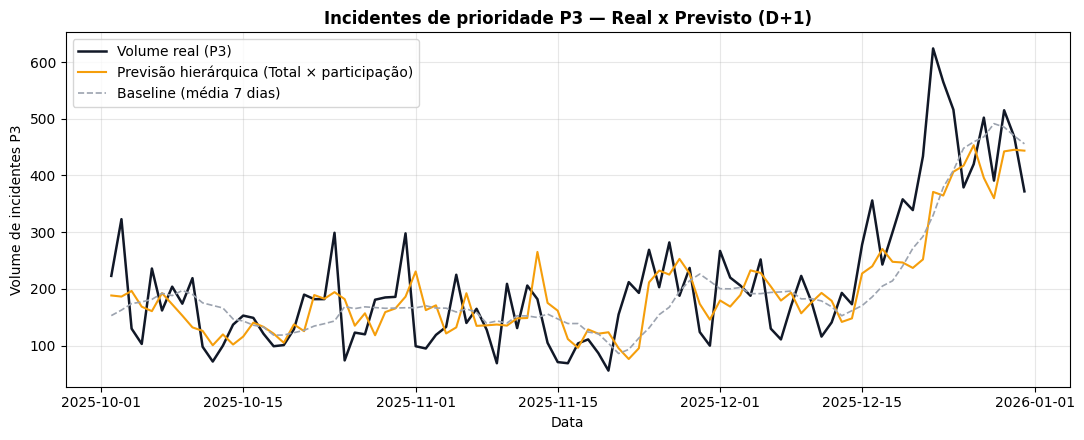

In [ ]:
fig, ax = plt.subplots()
ax.plot(datas_p3, reais_p3, label='Volume real (P3)', color='#111827', linewidth=1.8)
ax.plot(datas_p3, previstos_p3, label='Previsão hierárquica (Total × participação)', color='#f59e0b', linewidth=1.5)
ax.plot(datas_p3, baseline_p3, label='Baseline (média 7 dias)', color='#9ca3af', linewidth=1.2, linestyle='--')
ax.set_title('Incidentes de prioridade P3 — Real x Previsto (D+1)', fontsize=12, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Volume de incidentes P3')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Abordagem hierárquica: MAE 57,3 contra 59,6 do baseline (+3,7%). Superior em 2 das 3
janelas; a restante ficou aproximadamente empatada. O ganho é pequeno e ainda exige
validação com novos períodos.

**Status: Experimental / evidência inicial.**

A previsão de uma prioridade volátil funcionou melhor condicionada à previsão da demanda
total do que como série independente.

## 8. Comparação Consolidada

In [ ]:
comparacao_final = pd.DataFrame([
    {'Capacidade': 'D+1 Total', 'Abordagem': 'RandomForest', 'Baseline': 'media_7d',
     'MAE baseline': round(mae_baseline_d1, 1), 'MAE modelo': round(mae_modelo_d1, 1),
     'Melhoria': f'{melhoria_d1:+.1f}%', 'Estabilidade': f'{janelas_positivas_d1}/{len(tabela_d1)} janelas',
     'Status': 'Validado com ressalvas'},
    {'Capacidade': 'D+7 Total', 'Abordagem': 'Ridge multi-horizonte', 'Baseline': 'volume dos 7 dias anteriores',
     'MAE baseline': round(mae_baseline_d7, 1), 'MAE modelo': round(mae_modelo_d7, 1),
     'Melhoria': f'{melhoria_d7:+.1f}%', 'Estabilidade': f'{janelas_positivas_d7}/{len(tabela_d7)} janelas, N={len(reais_d7)}',
     'Status': 'Experimental'},
    {'Capacidade': 'P2 D+1', 'Abordagem': 'ElasticNet', 'Baseline': 'sazonal_dow',
     'MAE baseline': round(mae_baseline_p2, 1), 'MAE modelo': round(mae_modelo_p2, 1),
     'Melhoria': f'{melhoria_p2:+.1f}%', 'Estabilidade': f'{janelas_positivas_p2}/{len(tabela_p2)} janelas',
     'Status': 'Validado com ressalvas'},
    {'Capacidade': 'P3 D+1', 'Abordagem': 'Hierárquico (Total × participação)', 'Baseline': 'media_7d',
     'MAE baseline': round(mae_baseline_p3, 1), 'MAE modelo': round(mae_modelo_p3, 1),
     'Melhoria': f'{melhoria_p3:+.1f}%', 'Estabilidade': f'{janelas_positivas_p3}/{len(tabela_p3)} janelas',
     'Status': 'Experimental / evidência inicial'},
])
comparacao_final

,Capacidade,Abordagem,Baseline,MAE baseline,MAE modelo,Melhoria,Estabilidade,Status
0,D+1 Total,RandomForest,media_7d,128.2,117.6,+8.2%,2/3 janelas,Validado com ressalvas
1,D+7 Total,Ridge multi-horizonte,volume dos 7 dias anteriores,782.5,594.6,+24.0%,"2/2 janelas, N=12",Experimental
2,P2 D+1,ElasticNet,sazonal_dow,52.4,49.8,+5.1%,2/3 janelas,Validado com ressalvas
3,P3 D+1,Hierárquico (Total × participação),media_7d,59.6,57.3,+3.7%,2/3 janelas,Experimental / evidência inicial


## 9. Limitações

- Mudança de regime a partir de set/2025, com o treino restrito a esse período.
- Histórico recente limitado (~120 observações), poucas janelas walk-forward.
- D+7: apenas 12 previsões independentes.
- P2: instabilidade na janela mais recente, agravada após correção do baseline.
- P3: ganho pequeno, da mesma ordem da variação entre janelas.
- Seleção de modelos e baselines feita sobre o mesmo conjunto de validação disponível.
- Resultados devem ser revalidados com mais dados.

## 10. Conclusão

O Motor Preditivo é mais robusto em D+1 total. D+7 tem ganho relevante, mas permanece
experimental pela amostra reduzida. P2 mostra sinal com instabilidade temporal; P3 mostra
evidência inicial via abordagem hierárquica.

## Evidências para apresentação

- Gráfico Real × Previsto — D+1 (Seção 4)
- Gráfico Real × Previsto — D+7 (Seção 5)
- Gráfico Real × Previsto — P2 (Seção 6)
- Gráfico Real × Previsto — P3 (Seção 7)
- Tabela consolidada (Seção 8)